# Using the Planck map as a dust model

I'm not happy with the Green+Zucker maps at high distances - this very quickly gets outside of their reliable distance range. So, what about using the Planck map?

## Imports

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from dustmaps.planck import fetch as fetch_planck, PlanckQuery
from dustmaps.bayestar import BayestarQuery
from dustmaps.decaps import DECaPSQueryLite
from astropy.coordinates import SkyCoord, galactocentric_frame_defaults
from astropy import units as u
from scipy.stats import truncexpon

In [2]:
# fetch_planck()

In [3]:
planck = PlanckQuery()
bayestar = BayestarQuery(max_samples=1)
decaps = DECaPSQueryLite(mean_only=True)

Loading pixel_info ...
Loading samples ...
Loading best_fit ...
Replacing NaNs in reliable distance estimates ...
Sorting pixel_info ...
Extracting hp_idx_sorted and data_idx at each nside ...
  nside = 64
  nside = 128
  nside = 256
  nside = 512
  nside = 1024
t = 16.986 s
  pix_info:   0.445 s
   samples:   3.247 s
      best:   2.876 s
       nan:   0.023 s
      sort:  10.280 s
       idx:   0.114 s
Loading meta pixel info...
Meta pixel info loaded!


## A first look at the Planck map

In [4]:
x_values = np.linspace(-180, 180, endpoint=False, num=200)
y_values = np.linspace(-90, 90, num=100)
x, y = [array.flatten() for array in np.meshgrid(x_values, y_values)]

coords = SkyCoord(l=x, b=y, unit="deg", frame="galactic")

reddening = planck.query(coords).reshape(y_values.size, x_values.size)


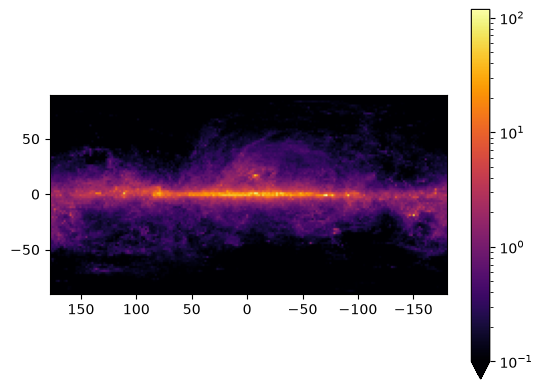

In [5]:
plt.imshow(
    reddening * 3.1,
    origin="lower",
    norm="log",
    cmap="inferno",
    vmin=0.1,
    extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()),
)
plt.gca().invert_xaxis()
plt.colorbar(extend="min")

Well shit, it goes up to A_V of ~100! This dust map doesn't fuck around.

## Projecting it into 3D

### First off: what is a max distance?

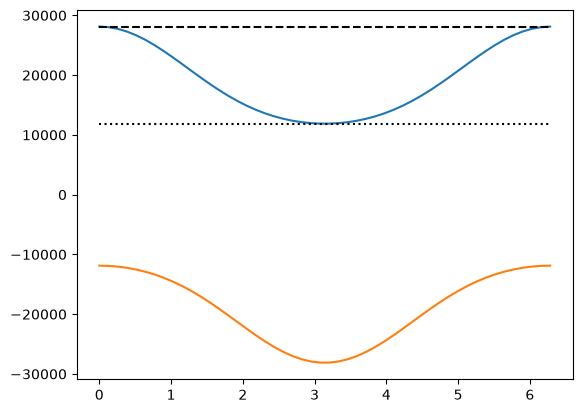

In [6]:
l = np.radians(np.linspace(0, 360))

r_sun = 8122
r_gal = 20000
r_sun_cos_l = r_sun * np.cos(l)
sqrt_part = np.sqrt(4*r_sun_cos_l**2 - 4*(r_sun**2 - r_gal**2))

d_max_upper = (2*r_sun_cos_l + sqrt_part) / 2
d_max_lower = (2*r_sun_cos_l - sqrt_part) / 2

plt.plot(l, d_max_upper)
plt.plot(l, d_max_lower)
plt.plot([0, 2*np.pi], [r_sun + r_gal]*2, 'k--')
plt.plot([0, 2*np.pi], [r_gal - r_sun]*2, 'k:')

Yay! That's a well-behaved function and I can just use the upper solution. Perfect.

### How do I add an exponential model?

Dust is closer to the Galactic center

In [121]:
model = truncexpon(20000/3000, scale=3000)

l = 90
b = 0
points = 50
distances = np.linspace(0, 25000, num=points)

coords = SkyCoord(
    l=np.full(points, l) * u.deg,
    b=np.full(points, b) * u.deg,
    distance=distances * u.pc,
    frame="galactic",
).transform_to("galactocentric").represent_as("cylindrical")

rho = coords.rho.value

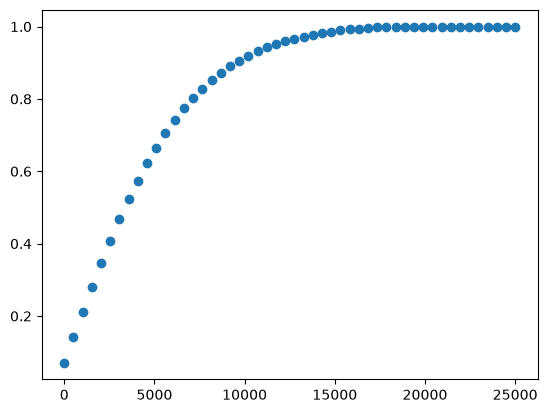

In [122]:
pdf_cumulative = np.cumsum(model.pdf(rho))
pdf_cumulative /= pdf_cumulative.max()
plt.scatter(distances, pdf_cumulative)

### Some helpers

In [136]:
DEFAULT_R_SUN = galactocentric_frame_defaults.get()["galcen_distance"].to(u.pc).value


class PlanckQuery3D:
    def __init__(
        self,
        max_distance=20000,
        scale_length=3000,
        expon_integral_resolution=50,
        r_sun=DEFAULT_R_SUN,
        r_v=3.1,
    ):
        # Todo reference to out of class object; remove in final code
        self._dust_map = planck
        self.max_distance = max_distance
        self.expon_model = truncexpon(max_distance / scale_length, scale=scale_length)
        self.expon_integral_resolution = expon_integral_resolution
        self.r_sun = r_sun
        self.r_v = r_v

    def query(self, coords, mode="linear"):
        coords = coords.transform_to("galactic")
        l_degrees = coords.l.to(u.deg).value
        distance = coords.distance.to(u.pc).value
        max_distances = self._calculate_maximum_distance(l_degrees)
        total_extinctions = self.r_v * self._dust_map.query(coords)

        if mode == "linear":
            distance_fractions = np.clip(distance / max_distances, 0, 1)
            return distance_fractions * total_extinctions

        elif mode == "expon":
            distance_clipped = np.clip(distance, 0, max_distances)
            distance_integrals = np.linspace(
                np.zeros(len(max_distances)),
                max_distances,
                num=self.expon_integral_resolution,
            ).T
            rho_integrals = self._calculate_galactocentric_radius(
                l_degrees.reshape(-1, 1), distance_integrals
            )
            pdf_values = self.expon_model.pdf(rho_integrals)
            cumulative_pdf_values = np.cumsum(pdf_values, axis=1)
            cumulative_pdf_values /= np.max(cumulative_pdf_values, axis=1).reshape(
                -1, 1
            )
            extinction_fraction = np.asarray(
                [
                    np.interp(d, d_i, c_i)
                    for d, d_i, c_i in zip(
                        distance_clipped, distance_integrals, cumulative_pdf_values
                    )
                ]
            )
            return extinction_fraction * total_extinctions

        else:
            raise ValueError(f"selected mode '{mode}' not recognized.")

    def _calculate_maximum_distance(self, l_degrees):
        r_sun_cos_l = 2 * self.r_sun * np.cos(np.radians(l_degrees))
        return (
            r_sun_cos_l
            + np.sqrt(r_sun_cos_l**2 - 4 * (self.r_sun**2 - self.max_distance**2))
        ) / 2

    def _calculate_galactocentric_radius(self, l_degrees, distance):
        return np.sqrt(
            distance**2
            + r_sun**2
            - 2 * distance * self.r_sun * np.cos(np.radians(l_degrees))
        )


In [137]:
planck_3d = PlanckQuery3D()

In [138]:
np.linspace([0, 1], [4, 5]).T.sum(axis=1)

array([100., 150.])

In [139]:
SkyCoord

astropy.coordinates.sky_coordinate.SkyCoord

### Try it out in the region

In [140]:
l_values = np.linspace(0, 360, endpoint=False, num=90)
distances = np.linspace(0, 20000, num=20)

l, d = [array.flatten() for array in np.meshgrid(l_values, distances)]
b = np.zeros(len(l))

coords = SkyCoord(l=l*u.deg, b=b*u.deg, distance=d*u.pc, frame="galactic")

In [141]:
planck_dust = planck_3d.query(coords, mode="expon")
bayestar_dust = 3.1 * bayestar.query(coords, mode="best")
decaps_dust = 3.1 * decaps.query(coords)

/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/dustmaps/bayestar.py:432: RuntimeWarning: divide by zero encountered in log10
  dm = 5. * (np.log10(d) + 2.)
/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/dustmaps/decaps.py:864: RuntimeWarning: divide by zero encountered in log10
  dm = 5. * (np.log10(d) + 2.)


[None, None]

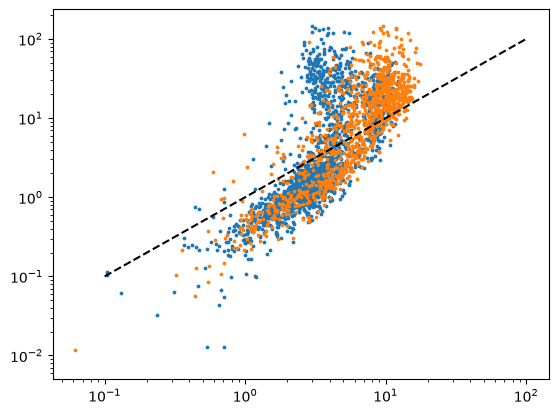

In [185]:
plt.scatter(bayestar_dust, planck_dust, s=3)
plt.scatter(decaps_dust, planck_dust, s=3)
plt.plot([0.1, 100], [0.1, 100], 'k--')
plt.gca().set(xscale="log", yscale="log")

### Try it out on a grid

In [162]:
resolution = 50

xy_range = 8000
x_center = -6000

x_values = np.linspace(
    -xy_range + x_center, xy_range + x_center, endpoint=False, num=resolution
)
y_values = np.linspace(-xy_range, xy_range, num=resolution)

x, y = [array.flatten() for array in np.meshgrid(x_values, y_values)]
z = np.zeros(len(x)) - 18

coords = SkyCoord(
    x=x * u.pc,
    y=y * u.pc,
    z=z * u.pc,
    frame="galactocentric",
    representation_type="cartesian",
)

In [163]:
planck_dust = planck_3d.query(coords).reshape(resolution, resolution)
planck_dust_expon = planck_3d.query(coords, mode="expon").reshape(resolution, resolution)
bayestar_dust = (
    3.1 * 0.84 * bayestar.query(coords, mode="best").reshape(resolution, resolution)
)
decaps_dust = 3.1 * decaps.query(coords).reshape(resolution, resolution)

In [164]:
base_dust = np.where(np.isfinite(decaps_dust), decaps_dust, bayestar_dust)
max_dust = np.where(planck_dust > base_dust, planck_dust, base_dust)
max_dust_expon = np.where(planck_dust_expon > base_dust, planck_dust_expon, base_dust)

/tmp/ipykernel_15551/3059329767.py:20: RuntimeWarning: divide by zero encountered in divide
  image_ratio = ax[4].imshow(max_dust_expon / base_dust, extent=extent, norm="log")


[Text(0.5, 1.0, 'Best / Bayestar19+DECaPS')]

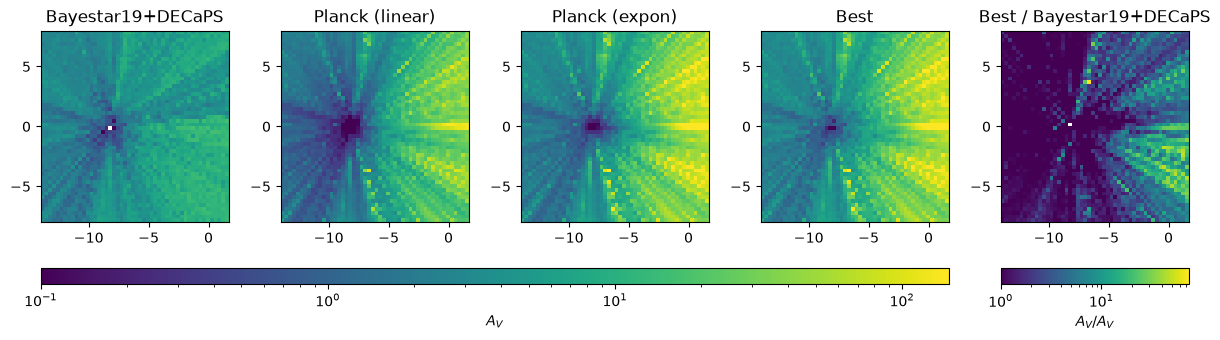

In [182]:
fig, ax = plt.subplots(ncols=5, figsize=(12, 5), layout="constrained")

max_dust = planck_dust.max()

extent = [
    x_values.min() * 1e-3,
    x_values.max() * 1e-3,
    y_values.min() * 1e-3,
    y_values.max() * 1e-3,
]

common_kwargs = dict(
    origin="lower", vmin=0.1, vmax=max_dust, cmap="viridis", extent=extent, norm="log"
)

ax[0].imshow(base_dust, **common_kwargs)
ax[1].imshow(planck_dust, **common_kwargs)
ax[2].imshow(planck_dust_expon, **common_kwargs)
image = ax[3].imshow(max_dust_expon, **common_kwargs)
image_ratio = ax[4].imshow(max_dust_expon / base_dust, extent=extent, norm="log")

fig.colorbar(image, ax=ax[:-1], orientation="horizontal", aspect=60, label="$A_V$")
fig.colorbar(image_ratio, ax=ax[-1], orientation="horizontal", aspect=12, label="$A_V / A_V$")

ax[0].set(title="Bayestar19+DECaPS")
ax[1].set(title="Planck (linear)")
ax[2].set(title="Planck (expon)")
ax[3].set(title="Best")
ax[4].set(title="Best / Bayestar19+DECaPS")
# ax[0].scatter(x, y, c=decaps_dust, s=5, norm="log", vmax=100)

# ax[1].scatter(x, y, c=planck_dust, s=5, norm="log", vmax=100)